# Introduction

This project focuses on forecasting monthly car sales using time series analysis. The aim is to explore the dataset, prepare it for modelling, and define a consistent forecasting problem for all group members.

The dataset contains monthly car sales observations and is suitable for forecasting because it shows time dependence, trend, and seasonality. These characteristics make it appropriate for models such as ARIMA, SARIMA, and LSTM.

This notebook contains the shared group work, including data loading, cleaning, exploratory data analysis, preprocessing, and the definition of the forecasting task.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

# Dataset Loading

The dataset is loaded from the project folder. It contains monthly observations of car sales. Before modelling, the structure of the data needs to be checked to confirm the variable names, data types, and general formatting.

In [16]:
df = pd.read_csv("../Data/monthly-car-sales.csv")
df.head()

,Month,Sales
0,1960-01,6550
1,1960-02,8728
2,1960-03,12026
3,1960-04,14395
4,1960-05,14587


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Month   108 non-null    str  
 1   Sales   108 non-null    int64
dtypes: int64(1), str(1)
memory usage: 1.8 KB


In [18]:
df.describe()

,Sales
count,108.000000
mean,14595.111111
std,4525.213913
min,5568.000000
25%,11391.250000
50%,14076.000000
75%,17595.750000
max,26099.000000


# Data Cleaning

To prepare the dataset for time series analysis, the date column must be converted into datetime format and set as the index. This ensures that the data is treated as a chronological time series.

The dataset is also checked for missing values and duplicate entries. These checks are important because missing or inconsistent observations can negatively affect forecasting performance.

In [19]:
df.columns = ["Date", "Sales"]
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.set_index("Date", inplace=True)

df.head()

,Sales
Date,
1960-01-01,6550
1960-02-01,8728
1960-03-01,12026
1960-04-01,14395
1960-05-01,14587


In [20]:
df.isnull().sum()

Sales    0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis

Exploratory analysis is used to identify the main properties of the time series. In forecasting, it is especially important to examine:

- overall trend
- possible seasonality
- variation over time
- unusual fluctuations or outliers

Understanding these patterns helps justify model selection later.

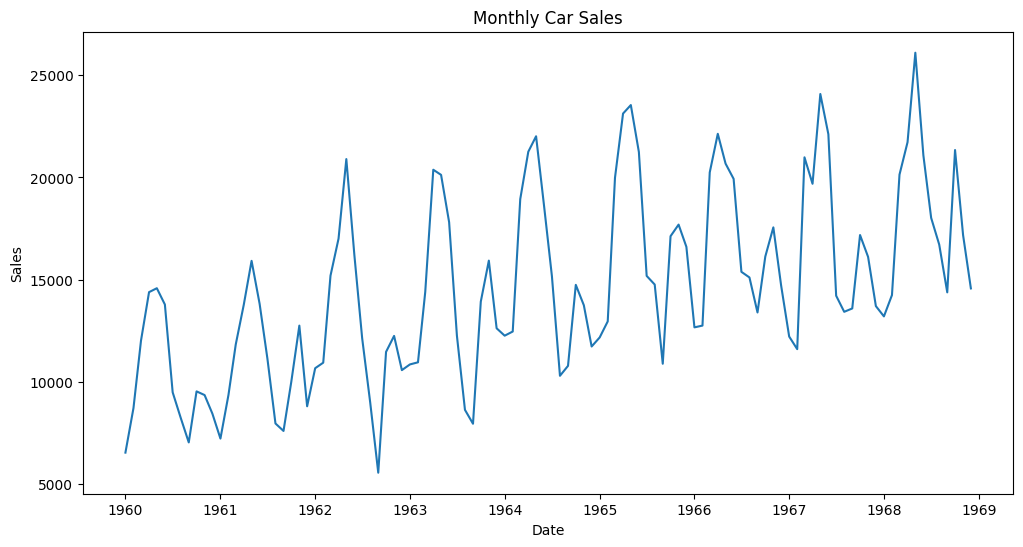

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Sales"])
plt.title("Monthly Car Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

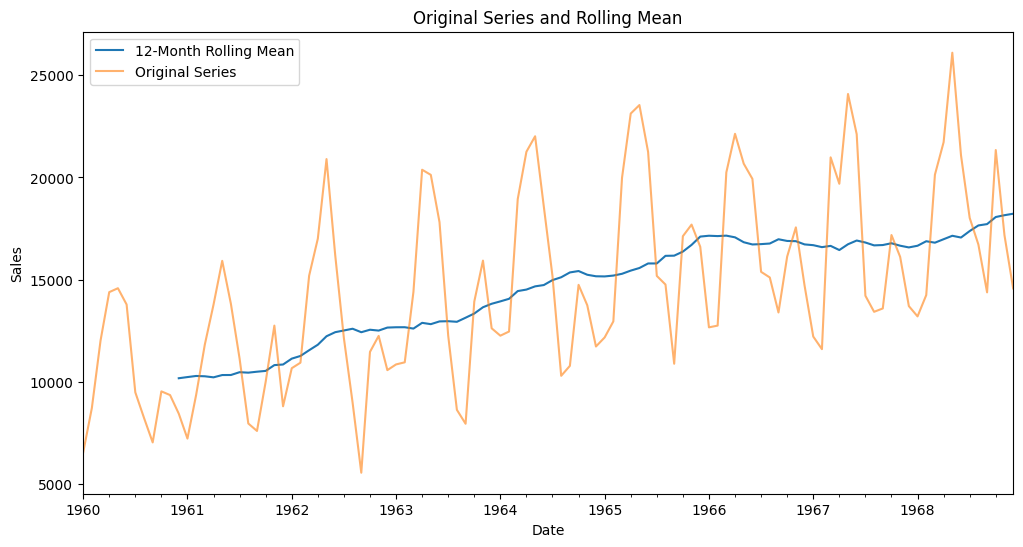

In [23]:
plt.figure(figsize=(12, 6))
df["Sales"].rolling(window=12).mean().plot(label="12-Month Rolling Mean")
df["Sales"].plot(alpha=0.6, label="Original Series")
plt.title("Original Series and Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

The time series plot suggests that the data contains both trend and repeating seasonal fluctuations. The rolling mean also changes over time, which indicates that the series is likely non-stationary.

Because seasonal behaviour appears to repeat over a yearly cycle, this dataset is especially suitable for comparing ARIMA and SARIMA models.

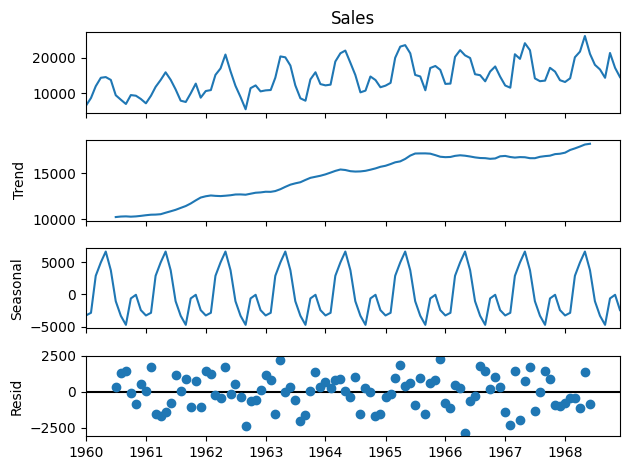

In [24]:
decomposition = seasonal_decompose(df["Sales"], model="additive", period=12)
decomposition.plot()
plt.show()

# Stationarity Analysis

Stationarity is an important concept in time series forecasting. A stationary series has statistical properties such as mean and variance that remain stable over time.

Many classical forecasting models, especially ARIMA-type models, assume stationarity. The Augmented Dickey-Fuller test is used to assess whether the original series is stationary.

In [25]:
adf_result = adfuller(df["Sales"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -1.223812766175284
p-value: 0.6632691049832868
Critical Values:
1%: -3.5011373281819504
5%: -2.8924800524857854
10%: -2.5832749307479226


If the p-value is greater than 0.05, the null hypothesis of non-stationarity cannot be rejected. In that case, the series is considered non-stationary and will require differencing in later models.

# Forecasting Problem Definition

The forecasting task is defined as follows:

- Target variable: monthly car sales
- Forecast horizon: 12 months
- Data frequency: monthly
- Model comparison: ARIMA, SARIMA, and LSTM
- Baselines: naive, seasonal naive, and mean forecast

The last 12 months are reserved as the test set so that all group members evaluate their models on the same unseen period.

In [26]:
train = df[:-12]
test = df[-12:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (96, 1)
Test shape: (12, 1)


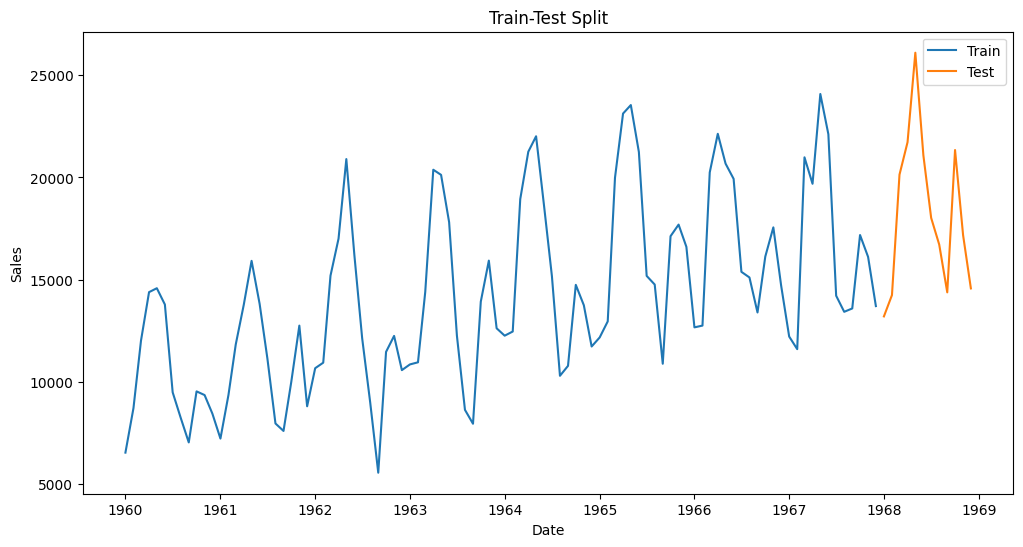

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train["Sales"], label="Train")
plt.plot(test.index, test["Sales"], label="Test")
plt.title("Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

# Validation Strategy

A hold-out validation strategy is used in this project. The training set contains the earlier observations, while the final 12 months form the test set.

This approach is appropriate because it reflects a real forecasting scenario in which future values are predicted using only past information.

# Evaluation Metrics

The models will be compared using the following metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

MAE gives the average absolute size of errors, while RMSE penalizes larger forecasting errors more strongly. Using both metrics provides a more balanced evaluation.

In [28]:
df.to_csv("../Data/cleaned_sales_data.csv")

# Conclusion

The dataset is clean and suitable for forecasting. It shows clear trend and seasonality, making it a strong candidate for comparing classical and deep learning approaches.

The shared preprocessing and forecasting setup established here will be used consistently across all individual notebooks to ensure a fair comparison of results.